In [1]:
from typing import Dict, List
from model_ranking import (
    get_transformer_results_aug_sweep,
    extract_values_at_index,
    plot_performance_vs_transfer_metric,
)

INFO: P [MainThread] 2025-09-26 12:17:21,784 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
selected_augmentations: Dict[str, List[str]] = {
    "none": [],
    "gauss": ["a001-003"],
}
source_models = {
    "Micro_SAM": ['vit_t_lm', 'vit_b_lm', 'vit_l_lm'],
    # "SAM": ['vit_t', 'vit_b', 'vit_l']
}
base_dir_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation"

In [3]:
direct_eval_results, p_eval_results, consis_results = get_transformer_results_aug_sweep(
    source_models=source_models,
    selected_augmentations=selected_augmentations,
    eval_key="mSA_scores_median",
    output_folder="256x256/prediction_split",
    base_dir_path=base_dir_path,
)

In [4]:
consis_results

{'vit_t_lm': {'gauss': array([0.53102112])},
 'vit_b_lm': {'gauss': array([0.26296419])},
 'vit_l_lm': {'gauss': array([0.24023719])}}

In [5]:
direct_eval_results

{'vit_t_lm': 0.15816751680471108,
 'vit_b_lm': 0.15202787979526838,
 'vit_l_lm': 0.2176869655808612}

Augmentation type: none
Augmentation type: gauss
  Index 0: Alpha a001-003


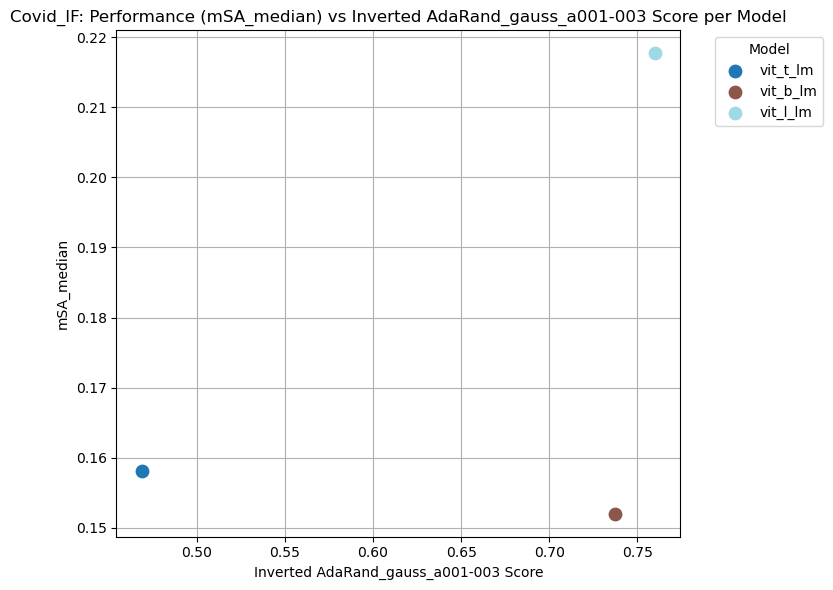

In [6]:
for aug_type, alphas in selected_augmentations.items():
    print(f"Augmentation type: {aug_type}")
    for i, alpha in enumerate(alphas):
        print(f"  Index {i}: Alpha {alpha}")

        consis_scores = extract_values_at_index(consis_results, aug_type, i)

        _ = plot_performance_vs_transfer_metric(
            performance_scores=direct_eval_results,
            transfer_metrics=consis_scores,
            target="Covid_IF",
            metric_name=f"Inverted AdaRand_{aug_type}_{alpha}",
            performance_metric_name="mSA_median",
            invert_transfer_metric=True,
        )